In [ ]:
# NLP ANN

In [ ]:
# importing dependancies
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
# tensorflow
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Dense
# SKLEARN
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,accuracy_score
# IMBLEARN
from imblearn.over_sampling import SMOTE

In [ ]:
# Connecting Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/Dataset

 AmazonReview.csv     'Student Mental health.csv'
 Churn_Modelling.csv  'Student Mental health.gsheet'
 Fish.csv


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Dataset/Churn_Modelling.csv")

In [ ]:
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
data.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [ ]:
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
# Checking null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [ ]:
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


0    7963
1    2037
Name: Exited, dtype: int64


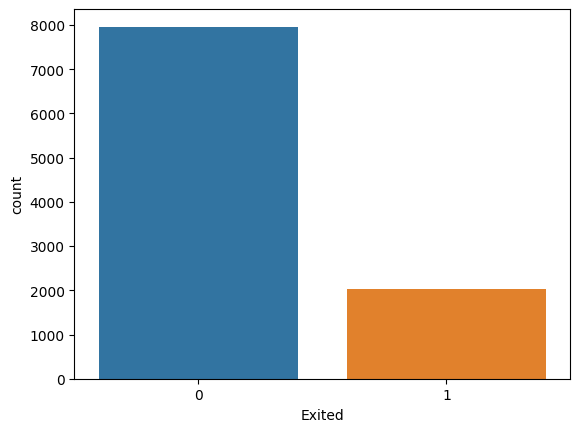

In [ ]:
# Graph
import matplotlib.pyplot as mlt
import seaborn as sns
print(data['Exited'].value_counts())
sns.countplot(data,x='Exited')
mlt.show()

In [ ]:
# Dividing into target and feature column
x = data.iloc[:,:-1]
y = data.iloc[:,-1]

In [ ]:
# # Graph
# import matplotlib.pyplot as mlt
# import seaborn as sns
# print(data['Exited'].value_counts())
# sns.countplot(data)
# mlt.show()

In [ ]:
print("X :")
x

X :


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [ ]:
print("Y : ")
y

Y : 


0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [ ]:
# Encoding the value of x(Country)
le = LabelEncoder()
x['Geography'] = le.fit_transform(x['Geography'])
x

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,Female,42,2,0.00,1,1,1,101348.88
1,608,2,Female,41,1,83807.86,1,0,1,112542.58
2,502,0,Female,42,8,159660.80,3,1,0,113931.57
3,699,0,Female,39,1,0.00,2,0,0,93826.63
4,850,2,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,Male,39,5,0.00,2,1,0,96270.64
9996,516,0,Male,35,10,57369.61,1,1,1,101699.77
9997,709,0,Female,36,7,0.00,1,0,1,42085.58
9998,772,1,Male,42,3,75075.31,2,1,0,92888.52


In [ ]:
# OneHot Encoding the value of x(Gender) using get dummies
x_dummies = pd.get_dummies(data=x,columns=['Gender'])
x_dummies.drop('Gender_Female',axis=1,inplace=True)
x_dummies

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male
0,619,0,42,2,0.00,1,1,1,101348.88,0
1,608,2,41,1,83807.86,1,0,1,112542.58,0
2,502,0,42,8,159660.80,3,1,0,113931.57,0
3,699,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,39,5,0.00,2,1,0,96270.64,1
9996,516,0,35,10,57369.61,1,1,1,101699.77,1
9997,709,0,36,7,0.00,1,0,1,42085.58,0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [2])], remainder='drop')
X = pd.DataFrame(np.array(ct.fit_transform(x)))
X
x['Gender_Male'] = X[1]
x['Gender_Female'] = X[0]
x.drop(['Gender','Gender_Male'],axis=1,inplace=True)

In [ ]:
x

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Female
0,619,0,42,2,0.00,1,1,1,101348.88,1.0
1,608,2,41,1,83807.86,1,0,1,112542.58,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1.0
3,699,0,39,1,0.00,2,0,0,93826.63,1.0
4,850,2,43,2,125510.82,1,1,1,79084.10,1.0
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,39,5,0.00,2,1,0,96270.64,0.0
9996,516,0,35,10,57369.61,1,1,1,101699.77,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,0.0


In [ ]:
# applying smote technique for reducing iver sampling
sm = SMOTE(k_neighbors=5, random_state=5)
x, y = sm.fit_resample(x, y)

In [ ]:
scalar = StandardScaler()
x = scalar.fit_transform(x)
x = pd.DataFrame(np.array(x))

In [ ]:
x

,0,1,2,3,4,5,6,7,8,9
0,-0.321377,-0.896473,0.103534,-1.028371,-1.342888,-0.736171,0.777479,1.309038,-0.000208,1.078144
1,-0.441390,1.753347,0.003274,-1.394454,0.026398,-0.736171,-1.286209,1.309038,0.194082,1.078144
2,-1.597881,-0.896473,0.103534,1.168129,1.265714,2.755268,0.777479,-0.763920,0.218191,1.078144
3,0.551446,-0.896473,-0.197247,-1.394454,-1.342888,1.009549,-1.286209,-0.763920,-0.130771,1.078144
4,2.198900,1.753347,0.203794,-1.028371,0.707758,-0.736171,0.777479,1.309038,-0.386658,1.078144
...,...,...,...,...,...,...,...,...,...,...
15921,-0.910532,-0.896473,1.908215,-1.028371,-1.342888,-0.736171,-1.286209,-0.763920,-0.694858,1.078144
15922,-1.194200,0.428437,-0.297507,-0.662287,0.444286,-0.736171,-1.286209,-0.763920,-1.002064,0.149812
15923,0.616908,0.428437,0.003274,1.168129,1.095726,-0.736171,-1.286209,-0.763920,-1.026500,1.078144
15924,2.122528,0.428437,1.306654,0.802046,-1.342888,-0.736171,-1.286209,-0.763920,1.221999,1.078144


In [ ]:
# division of test train
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.20)

In [ ]:
# applying smote technique for reducing iver sampling
sm = SMOTE(k_neighbors=5, random_state=5)
xtrain, ytrain = sm.fit_resample(xtrain, ytrain)

In [ ]:
# Graph
import matplotlib.pyplot as mlt
import seaborn as sns
print(ytrain.value_counts())
# sns.countplot(ytrain)
# mlt.show()

1    6391
0    6391
Name: Exited, dtype: int64


In [ ]:
# create a model
model = Sequential(
    [
      layers.Dense(units=6,activation="relu",input_dim=10),
     layers.Dense(units=6,activation="relu"),
     layers.Dense(units=1,activation="sigmoid")
    ]
)

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 6)                 66        
                                                                 
 dense_1 (Dense)             (None, 6)                 42        
                                                                 
 dense_2 (Dense)             (None, 1)                 7         
                                                                 
Total params: 115
Trainable params: 115
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.weights

[<tf.Variable 'dense/kernel:0' shape=(10, 6) dtype=float32, numpy=
 array([[-0.1936535 ,  0.09446365,  0.21239036, -0.0504747 , -0.37344098,
          0.46783048],
        [ 0.16624486, -0.47459704,  0.5012706 ,  0.5699672 ,  0.17394543,
          0.43844384],
        [ 0.36799878, -0.16397414, -0.1860067 , -0.11515039, -0.11190027,
         -0.5232081 ],
        [ 0.08015364, -0.46695197, -0.5219876 , -0.59055394, -0.17571509,
         -0.38494396],
        [ 0.28757268,  0.6007337 , -0.00463468, -0.01509082, -0.34413233,
         -0.09296232],
        [-0.22741958,  0.5888552 , -0.3149885 , -0.1482094 , -0.5879148 ,
          0.2299797 ],
        [ 0.566323  ,  0.15879971,  0.01909006,  0.37650466,  0.01731586,
          0.24023902],
        [ 0.4770072 , -0.25168407, -0.41446042, -0.22253248,  0.4694795 ,
          0.534154  ],
        [-0.5054809 ,  0.33865565, -0.5569991 , -0.30476418,  0.43120462,
          0.07998967],
        [-0.4935592 , -0.13312542, -0.27961347,  0.00324124,

In [ ]:
len(model.weights)

6

In [ ]:
# Compiling ANN model
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

In [ ]:
history = model.fit(xtrain,ytrain,batch_size=32,epochs=50)

Epoch 1/50
400/400 [==============================] - 5s 5ms/step - loss: 0.6097 - accuracy: 0.6835
Epoch 2/50
400/400 [==============================] - 1s 3ms/step - loss: 0.5039 - accuracy: 0.7654
Epoch 3/50
400/400 [==============================] - 1s 2ms/step - loss: 0.4734 - accuracy: 0.7823
Epoch 4/50
400/400 [==============================] - 1s 2ms/step - loss: 0.4553 - accuracy: 0.7893
Epoch 5/50
400/400 [==============================] - 1s 3ms/step - loss: 0.4430 - accuracy: 0.7926
Epoch 6/50
400/400 [==============================] - 1s 3ms/step - loss: 0.4350 - accuracy: 0.7957
Epoch 7/50
400/400 [==============================] - 1s 2ms/step - loss: 0.4287 - accuracy: 0.8001
Epoch 8/50
400/400 [==============================] - 1s 2ms/step - loss: 0.4240 - accuracy: 0.8016
Epoch 9/50
400/400 [==============================] - 1s 2ms/step - loss: 0.4190 - accuracy: 0.8036
Epoch 10/50
400/400 [==============================] - 1s 2ms/step - loss: 0.4147 - accuracy: 0.8046

In [ ]:
# Comparing actual and predicted
ypred = model.predict(xtest)
ypred = (ypred > 0.5)
print(ypred)
# print(np.concatenate((ypred.reshape(len(ypred),1),ytest.reshape(len(ytest),1)),1))

100/100 [==============================] - 0s 1ms/step
[[False]
 [False]
 [False]
 ...
 [ True]
 [False]
 [ True]]


In [ ]:
# Confusion Matrix
cm = confusion_matrix(ytest,ypred)
print(cm)

[[1347  267]
 [ 266 1306]]


In [ ]:
# Classification Report
cr = classification_report(ytest,ypred)
print(cr)

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1614
           1       0.83      0.83      0.83      1572

    accuracy                           0.83      3186
   macro avg       0.83      0.83      0.83      3186
weighted avg       0.83      0.83      0.83      3186



In [ ]:
ascore = accuracy_score(ytest,ypred)
ascore*100

83.27055869428752

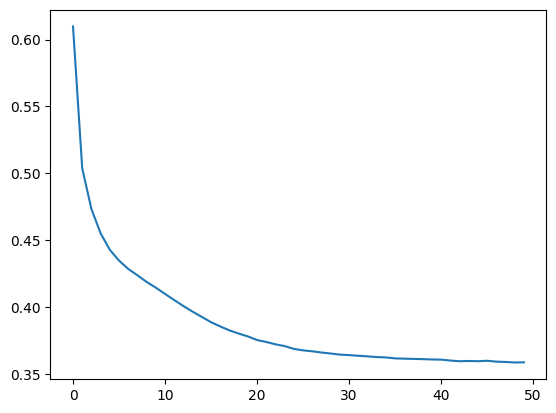

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])


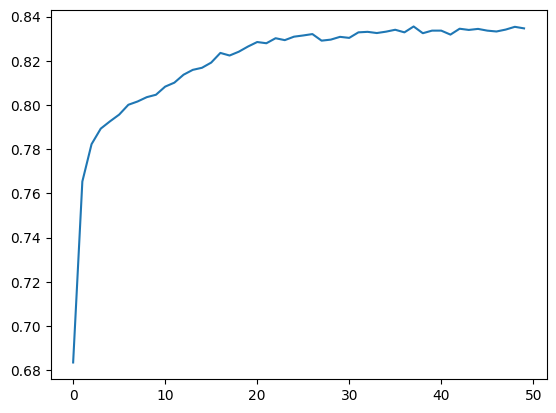

In [ ]:
plt.plot(history.history['accuracy'])
